# Evaluation Notebook

Evaluating the performance of the "Exit Advisor" agent using the conversations in 'sms_conversations.json'


## Setup

In [ ]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from dotenv import load_dotenv


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
load_dotenv()

from Advisors.ExitAdvisor.ExitAdvisor import ExitAdvisor
from app.Services.pdf_service import PDFService

## Exit Advisor triggering

In [2]:
#PDF_PATH = os.path.join(os.getcwd(), "..", "PythonDeveloperJobDescription.pdf")

PDF_PATH = os.path.join(os.getcwd(), "PythonDeveloperJobDescription.pdf")

job_description = PDFService.extract_text(PDF_PATH)

advisor = ExitAdvisor(job_description)

print("ExitAdvisor initialized.")
print(f"Job description length: {len(job_description)} characters")

ExitAdvisor initialized.
Job description length: 2872 characters


## Load & Parse

In [3]:
#DATA_PATH = os.path.join(os.getcwd(), "..", "sms_conversations.json")

DATA_PATH = os.path.join(os.getcwd(), "sms_conversations.json")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    conversations = json.load(f)

print(f"Loaded {len(conversations)} conversations")

Loaded 15 conversations


In [ ]:
def build_eval_samples(conversations):
    """
    For every labeled recruiter turn, build an eval sample:
      - history: all turns BEFORE this turn
      - message: the last candidate message before this turn
      - true_label: True if label == 'end', else False
    """
    samples = []

    for conv in conversations:
        turns = conv["turns"]
        history = []

        for i, turn in enumerate(turns):
            
            if turn["speaker"] == "recruiter" and turn.get("label"):

                
                candidate_message = ""
                for prev in reversed(turns[:i]):
                    if prev["speaker"] == "candidate":
                        candidate_message = prev["text"]
                        break

                if candidate_message:
                    samples.append({
                        "conversation_id": conv["conversation_id"],
                        "turn_id": turn["turn_id"],
                        "history": list(history),
                        "candidate_message": candidate_message,
                        "true_label": turn["label"] == "end",
                        "raw_label": turn["label"]
                    })

            
            if turn["speaker"] == "candidate":
                history.append({"user": turn["text"], "bot": ""})
            elif turn["speaker"] == "recruiter" and history:
                history[-1]["bot"] = turn["text"]

    return samples


samples = build_eval_samples(conversations)
print(f"Total eval samples: {len(samples)}")


df_samples = pd.DataFrame(samples)
print("\nLabel distribution:")
print(df_samples["raw_label"].value_counts())

Total eval samples: 44

Label distribution:
raw_label
schedule    19
end         15
continue    10
Name: count, dtype: int64


## RUN

In [5]:
print(f"Running ExitAdvisor on {len(samples)} samples...\n")

y_true = []
y_pred = []
results = []

for i, sample in enumerate(samples):
    prediction = advisor.should_end(sample["history"], sample["candidate_message"])

    y_true.append(sample["true_label"])
    y_pred.append(prediction)

    results.append({
        "conversation_id": sample["conversation_id"],
        "turn_id": sample["turn_id"],
        "candidate_message": sample["candidate_message"],
        "raw_label": sample["raw_label"],
        "true_end": sample["true_label"],
        "predicted_end": prediction,
        "correct": sample["true_label"] == prediction
    })

    status = "V" if sample["true_label"] == prediction else "X"
    print(f"[{status}] Conv {sample['conversation_id']} Turn {sample['turn_id']} "
          f"| label={sample['raw_label']:8s} | predicted_end={str(prediction):5s} "
          f"| '{sample['candidate_message'][:50]}'")

df_results = pd.DataFrame(results)
print(f"\nDone. Accuracy: {sum(r['correct'] for r in results)}/{len(results)}")

Running ExitAdvisor on 44 samples...

[V] Conv 1 Turn 3 | label=schedule | predicted_end=False | 'I've been using Python professionally for five yea'
[V] Conv 1 Turn 5 | label=schedule | predicted_end=False | 'I can't at that time—I'm busy.'
[V] Conv 1 Turn 7 | label=end      | predicted_end=True  | 'Monday at 3 PM is good.'
[V] Conv 2 Turn 3 | label=continue | predicted_end=False | 'I have three years' experience with Django and Fla'
[V] Conv 2 Turn 5 | label=continue | predicted_end=False | 'Could you share more about the company's cloud tec'
[X] Conv 2 Turn 7 | label=schedule | predicted_end=True  | 'Sounds great! I'd be happy to schedule a meeting'
[V] Conv 2 Turn 9 | label=end      | predicted_end=True  | 'Tuesday at 10 AM works.'
[V] Conv 3 Turn 3 | label=continue | predicted_end=False | 'Sure, I have four years of Python experience and t'
[V] Conv 3 Turn 5 | label=continue | predicted_end=False | 'Very comfortable, may I ask what technologies does'
[V] Conv 3 Turn 7 | label=end 

## Metrics

In [6]:
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)

print("=" * 40)
print("ExitAdvisor — Evaluation Results")
print("=" * 40)
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1 Score : {f1:.2%}")
print()
print(classification_report(y_true, y_pred, target_names=["Not End", "End"]))

ExitAdvisor — Evaluation Results
Accuracy : 97.73%
Precision: 93.75%
Recall   : 100.00%
F1 Score : 96.77%

              precision    recall  f1-score   support

     Not End       1.00      0.97      0.98        29
         End       0.94      1.00      0.97        15

    accuracy                           0.98        44
   macro avg       0.97      0.98      0.98        44
weighted avg       0.98      0.98      0.98        44



## Confusion Matrix

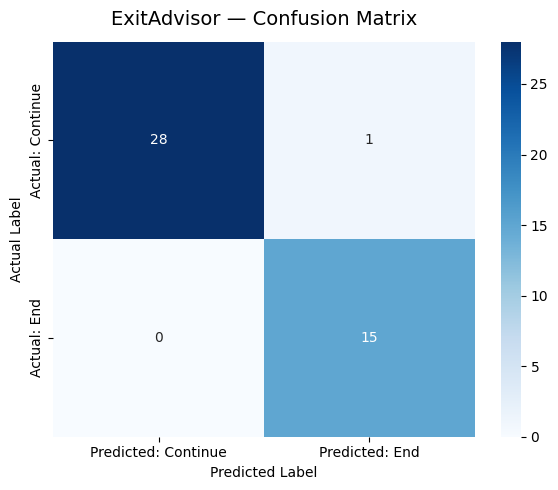

Saved: exit_advisor_confusion_matrix.png


In [7]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted: Continue", "Predicted: End"],
    yticklabels=["Actual: Continue", "Actual: End"],
    ax=ax
)
ax.set_title("ExitAdvisor — Confusion Matrix", fontsize=14, pad=12)
ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("exit_advisor_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: exit_advisor_confusion_matrix.png")

## Error Analysis

In [8]:
errors = df_results[df_results["correct"] == False].copy()

print(f"Total errors: {len(errors)}")
print()

# False Positives — predicted End but should Continue
fp = errors[(errors["predicted_end"] == True) & (errors["true_end"] == False)]
print(f"False Positives (wrongly ended): {len(fp)}")
for _, row in fp.iterrows():
    print(f"  Conv {row['conversation_id']} Turn {row['turn_id']} "
          f"[label={row['raw_label']}]: '{row['candidate_message']}'")

print()

# False Negatives — predicted Continue but should End
fn = errors[(errors["predicted_end"] == False) & (errors["true_end"] == True)]
print(f"False Negatives (missed end): {len(fn)}")
for _, row in fn.iterrows():
    print(f"  Conv {row['conversation_id']} Turn {row['turn_id']} "
          f"[label={row['raw_label']}]: '{row['candidate_message']}'")

Total errors: 1

False Positives (wrongly ended): 1
  Conv 2 Turn 7 [label=schedule]: 'Sounds great! I'd be happy to schedule a meeting'

False Negatives (missed end): 0


## Results Table

In [9]:
display_cols = ["conversation_id", "turn_id", "raw_label", "true_end", "predicted_end", "correct", "candidate_message"]
df_display = df_results[display_cols].copy()
df_display["candidate_message"] = df_display["candidate_message"].str[:60] + "..."

pd.set_option("display.max_colwidth", 80)
df_display

,conversation_id,turn_id,raw_label,true_end,predicted_end,correct,candidate_message
0,1,3,schedule,False,False,True,"I've been using Python professionally for five years, mostly..."
1,1,5,schedule,False,False,True,I can't at that time—I'm busy....
2,1,7,end,True,True,True,Monday at 3 PM is good....
3,2,3,continue,False,False,True,I have three years' experience with Django and Flask....
4,2,5,continue,False,False,True,Could you share more about the company's cloud technologies?...
5,2,7,schedule,False,True,False,Sounds great! I'd be happy to schedule a meeting...
6,2,9,end,True,True,True,Tuesday at 10 AM works....
7,3,3,continue,False,False,True,"Sure, I have four years of Python experience and two with SQ..."
8,3,5,continue,False,False,True,"Very comfortable, may I ask what technologies does the curre..."
9,3,7,end,True,True,True,"I would like to set an appointment, does Monday at 3 PM is g..."
